--- Acquiring Financial Data ---


/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_39281/1469238505.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  4 of 4 completed
/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_39281/1469238505.py:122: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full_data.fillna(method='ffill', inplace=True)
/var/folders/xd/kx89201x40lczm02gsvb4yym0000gn/T/ipykernel_39281/1469238505.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full_data.fillna(method='bfill', inplace=True) # For any initial NaNs


Financial data downloaded successfully.

--- Raw Combined Data Head ---
Ticker            AAPL        GOOG        MSFT        TLT
Date                                                     
2024-10-01  225.417633  167.835968  418.241638  95.376968
2024-10-02  225.985626  166.729813  414.702332  94.573212
2024-10-03  224.879517  166.630173  414.115784  93.682281
2024-10-04  226.005569  167.975479  413.638580  92.529907
2024-10-07  220.913483  163.819931  407.156525  91.832657

--- Raw Combined Data Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2024-10-01 to 2025-03-25
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    120 non-null    float64
 1   GOOG    120 non-null    float64
 2   MSFT    120 non-null    float64
 3   TLT     120 non-null    float64
dtypes: float64(4)
memory usage: 4.7 KB

--- Target KPIs Head (shifted) ---
            Avg_Tech_Return_Next_Day  Bond_Price_Change_Next_Day
Date

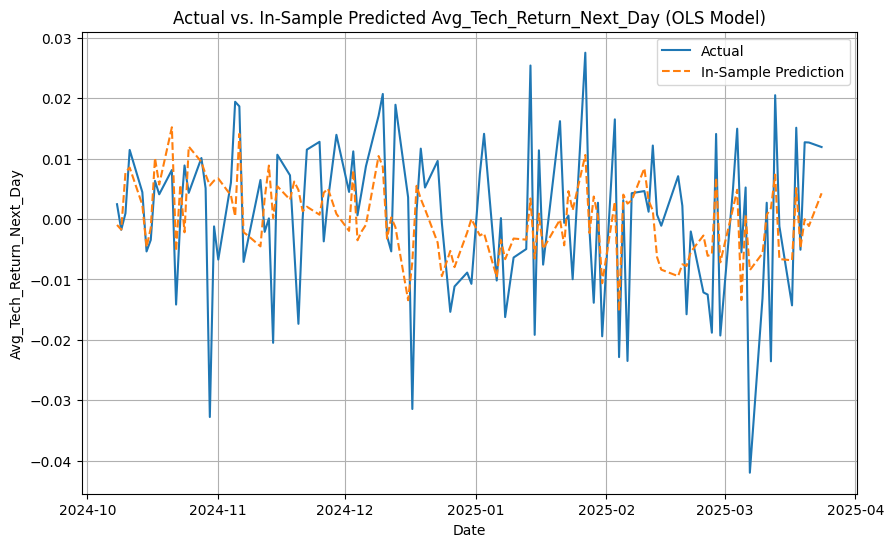


--- Training OLS Model for Bond_Price_Change_Next_Day ---
                                OLS Regression Results                                
Dep. Variable:     Bond_Price_Change_Next_Day   R-squared:                       0.286
Model:                                    OLS   Adj. R-squared:                  0.051
Method:                         Least Squares   F-statistic:                     1.215
Date:                        Sat, 05 Jul 2025   Prob (F-statistic):              0.245
Time:                                13:49:57   Log-Likelihood:                -111.53
No. Observations:                         114   AIC:                             281.1
Df Residuals:                              85   BIC:                             360.4
Df Model:                                  28                                         
Covariance Type:                    nonrobust                                         
                          coef    std err          t      P>|t|      [0

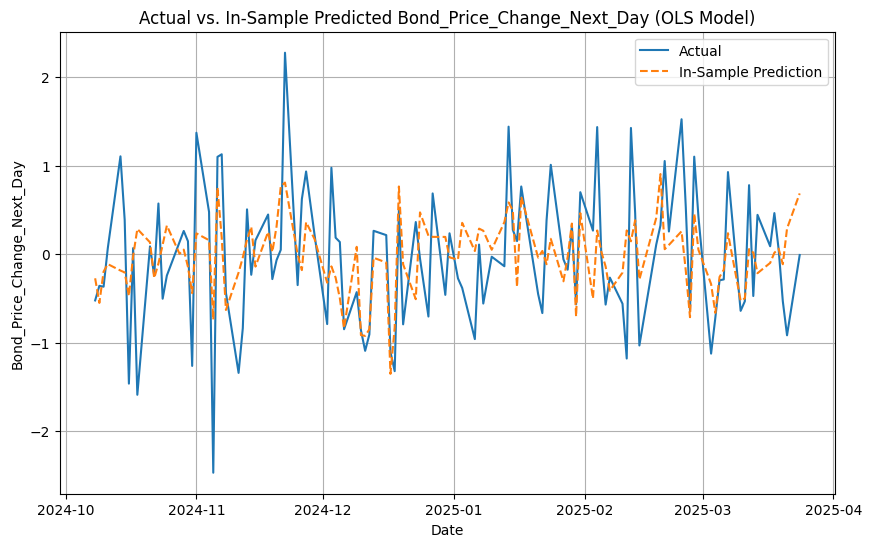


--- Demonstrating Future Prediction with the Trained OLS Models ---
Features for prediction are based on data up to 2025-03-24
Predicted Avg_Tech_Return_Next_Day for 2025-03-25: 0.0043
Predicted Bond_Price_Change_Next_Day for 2025-03-25: 0.6851

--- Important Note on Data Range ---
The data period used is from 2024-10-01 to 2025-03-26, providing significantly more data points.
This should allow the OLS models to learn more robust patterns compared to the very short previous range.
However, financial forecasting remains challenging, and the model's performance will depend on the
complexity of the patterns present in the data and the linearity assumption of OLS.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import statsmodels.api as sm # For OLS (Ordinary Least Squares)

# --- Part 1: Data Acquisition and Preprocessing ---

def get_financial_data(tickers, bond_ticker, start_date, end_date):
    """
    Downloads historical adjusted close prices for given tech stock tickers
    and a specified bond ticker.

    Args:
        tickers (list): List of stock ticker symbols (e.g., ['AAPL', 'MSFT', 'GOOGL']).
        bond_ticker (str): Ticker symbol for the bond ETF (e.g., 'TLT').
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
        pd.DataFrame: DataFrame with 'Adj Close' prices for each ticker (stocks and bond).
    """
    all_tickers = tickers + [bond_ticker]
    print(f"Downloading financial data for {all_tickers} from {start_date} to {end_date}...")
   
    # Download 'Close' prices for all tickers
    data = yf.download(all_tickers, start=start_date, end=end_date)['Close']
   
    # If downloading multiple tickers, 'Close' will be a MultiIndex, need to flatten
    if isinstance(data.columns, pd.MultiIndex):
        # Flatten MultiIndex columns, keeping the ticker symbol
        data.columns = [col[1] for col in data.columns]
   
    data.index = pd.to_datetime(data.index)
    print("Financial data downloaded successfully.")
    return data

def create_time_series_features(df, window_size=5, stock_cols=None, bond_col=None):
    """
    Creates time-series features like lagged values, rolling means, and daily returns.

    Args:
        df (pd.DataFrame): Input DataFrame with time-indexed data.
        window_size (int): Size of the rolling window for features.
        stock_cols (list): List of column names that represent stock prices.
        bond_col (str): Name of the column that represents bond prices.

    Returns:
        pd.DataFrame: DataFrame with engineered features.
    """
    print(f"Creating time-series features with window size {window_size}...")
    df_features = df.copy()

    for col in df.columns:
        # Lagged features
        for i in range(1, window_size + 1):
            df_features[f'{col}_lag_{i}'] = df[col].shift(i)

        # Rolling mean
        df_features[f'{col}_rolling_mean_{window_size}'] = df[col].rolling(window=window_size).mean()

        # Daily Returns (percentage change) - for stock and bond prices
        if stock_cols and col in stock_cols or bond_col and col == bond_col:
            df_features[f'{col}_daily_return'] = df[col].pct_change()

    # Drop rows with NaN values created by lagging/rolling operations
    df_features.dropna(inplace=True)
    print("Features created and NaN rows dropped.")
    return df_features

# --- Part 2: Linear Regression Modeling with statsmodels.api.OLS ---

def train_and_predict_ols(X_data, y_data):
    """
    Trains an Ordinary Least Squares (OLS) regression model
    using statsmodels and makes a prediction for a single new data point.

    Args:
        X_data (pd.DataFrame): DataFrame of features.
        y_data (pd.Series): Series of target values.

    Returns:
        tuple: (fitted_model, in_sample_predictions)
    """
    print(f"\n--- Training OLS Model for {y_data.name} ---")

    # Add a constant (intercept) to the features, which is good practice for OLS
    X_data = sm.add_constant(X_data)

    model = sm.OLS(y_data, X_data)
    fitted_model = model.fit()
    print(fitted_model.summary())

    in_sample_predictions = fitted_model.predict(X_data)
    return fitted_model, in_sample_predictions

# --- Main Execution ---

if __name__ == "__main__":
    # Define data period
    start_date = "2024-10-01"
    end_date = "2025-03-26"

    # Tech stock tickers
    tech_tickers = ['AAPL', 'MSFT', 'GOOG'] # Apple, Microsoft, Alphabet (Google)
    # Real Bond ETF ticker (iShares 20+ Year Treasury Bond ETF)
    bond_ticker = 'TLT'
    bond_col_name = 'TLT' # This will be the column name for bond prices

    # 1. Acquire Data
    print("--- Acquiring Financial Data ---")
    full_data = get_financial_data(tech_tickers, bond_ticker, start_date, end_date)

    # Ensure all required columns are present after download
    required_cols = tech_tickers + [bond_col_name]
    if not all(col in full_data.columns for col in required_cols):
        print(f"Error: Not all required columns ({required_cols}) found in downloaded data. Available columns: {full_data.columns}")
        exit()

    # Fill any missing data (e.g., weekends/holidays for stocks) using forward fill
    full_data.fillna(method='ffill', inplace=True)
    full_data.fillna(method='bfill', inplace=True) # For any initial NaNs

    if full_data.isnull().sum().sum() > 0:
        print("Warning: Missing values still present after fillna. Check data or dates.")
        print(full_data.isnull().sum())
        full_data.dropna(inplace=True) # Drop any remaining NaNs

    print("\n--- Raw Combined Data Head ---")
    print(full_data.head())
    print("\n--- Raw Combined Data Info ---")
    full_data.info()

    # 2. Define KPIs and Engineer Features
    # KPIs:
    # 1. Next day's average tech stock return
    # 2. Next day's Bond Price change (simple difference)

    # Calculate daily returns for tech stocks to get an average
    stock_returns = full_data[tech_tickers].pct_change().mean(axis=1) # Mean daily return across tech stocks
    stock_returns.name = 'Avg_Tech_Return' # Name the series for clarity

    # Calculate Bond Price change
    bond_price_change = full_data[bond_col_name].diff() # Simple daily change in bond price
    bond_price_change.name = 'Bond_Price_Change' # Name the series for clarity

    # Combine KPIs into a target DataFrame
    # Shift KPIs back to align with the features (we are predicting *future* KPIs)
    target_kpis = pd.DataFrame({
        'Avg_Tech_Return_Next_Day': stock_returns.shift(-1),
        'Bond_Price_Change_Next_Day': bond_price_change.shift(-1)
    }).dropna() # Drop the last row as its KPI cannot be calculated

    print("\n--- Target KPIs Head (shifted) ---")
    print(target_kpis.head())

    # Ensure full_data and target_kpis are aligned by index after shifts
    common_index = full_data.index.intersection(target_kpis.index)
    full_data_aligned = full_data.loc[common_index]
    target_kpis_aligned = target_kpis.loc[common_index]

    # Create features from the aligned full_data
    feature_window_size = 5 # Use 5 previous days' data to create features for prediction
    # Pass tech_tickers and bond_col_name to create_time_series_features
    features_df = create_time_series_features(full_data_aligned,
                                              window_size=feature_window_size,
                                              stock_cols=tech_tickers,
                                              bond_col=bond_col_name)

    # Align features_df with target_kpis_aligned after feature creation
    common_index_final = features_df.index.intersection(target_kpis_aligned.index)
    X = features_df.loc[common_index_final]
    y = target_kpis_aligned.loc[common_index_final]

    print(f"\nShape of X (features): {X.shape}")
    print(f"Shape of y (targets): {y.shape}")

    # Check if we have enough data after all transformations
    if X.shape[0] < 2: # Need at least 2 samples to fit any meaningful model
        print("Not enough data points after feature engineering. Adjust dates or simulation length.")
        exit()

    # 3. Build and Train OLS Models (one for each KPI)
    fitted_models = {}
    in_sample_preds = {}

    for kpi_name in y.columns:
        # Pass the full X and the specific KPI series to the OLS function
        fitted_model, in_sample_pred = train_and_predict_ols(X, y[kpi_name])
        fitted_models[kpi_name] = fitted_model
        in_sample_preds[kpi_name] = in_sample_pred

        # Plotting in-sample predictions for visual check
        plt.figure(figsize=(10, 6))
        plt.plot(y.index, y[kpi_name], label='Actual')
        plt.plot(y.index, in_sample_pred, label='In-Sample Prediction', linestyle='--')
        plt.xlabel("Date")
        plt.ylabel(kpi_name)
        plt.title(f"Actual vs. In-Sample Predicted {kpi_name} (OLS Model)")
        plt.legend()
        plt.grid(True)
        plt.show()

    # 4. Demonstrate Future Prediction
    print("\n--- Demonstrating Future Prediction with the Trained OLS Models ---")

    # To predict future KPIs, you need the last *row* of engineered features
    # from your historical data. This row will be the input for the next time step.
    last_known_features_df = X.iloc[-1:] # Get the last row of the features DataFrame
    print(f"Features for prediction are based on data up to {last_known_features_df.index[0].strftime('%Y-%m-%d')}")

    # Add the constant term for prediction, just like during training
    last_known_features_with_const = sm.add_constant(last_known_features_df, has_constant='add')

    predicted_kpis = {}
    # Determine the date for the predicted KPIs (the day after the last feature date)
    predicted_date = last_known_features_df.index[0] + timedelta(days=1)
    # Adjust for weekends/holidays to get to the next business day
    while predicted_date.weekday() > 4: # Monday=0, Sunday=6
        predicted_date += timedelta(days=1)

    for kpi_name, model in fitted_models.items():
        prediction = model.predict(last_known_features_with_const).iloc[0]
        predicted_kpis[kpi_name] = prediction
        print(f"Predicted {kpi_name} for {predicted_date.strftime('%Y-%m-%d')}: {prediction:.4f}")

    print("\n--- Important Note on Data Range ---")
    print(f"The data period used is from {start_date} to {end_date}, providing significantly more data points.")
    print("This should allow the OLS models to learn more robust patterns compared to the very short previous range.")
    print("However, financial forecasting remains challenging, and the model's performance will depend on the")
    print("complexity of the patterns present in the data and the linearity assumption of OLS.")